# Day 05 — Experimental
### #30DayChartChallenge | April 2026

**Mind the gap.** A dumbbell chart showing the gender gap in smoking — how far apart are men and women in each country? Indonesia has a 58 percentage point gap. France? Just 3.

**Data:**  
WHO age-standardized estimates via [World Population Review](https://worldpopulationreview.com/country-rankings/smoking-rates-by-country), 2025.  
Same dataset as Day 02.

**Author:** Sharfudeen Yasar Arafath

In [19]:
# — packages ------------------------------------------------------------------

library(ggplot2)
library(dplyr)
library(showtext)
library(sysfonts)

In [20]:
# — fonts & display size ------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
showtext_auto()
showtext_opts(dpi = 300)

# set notebook preview to match ggsave dimensions
options(repr.plot.width = 13, repr.plot.height = 10, repr.plot.res = 300)

In [21]:
# — read data -----------------------------------------------------------------

df <- read.csv("../../data/day_02/who_2024_smoking_prevalence_by_gender.csv",
               stringsAsFactors = FALSE)

# compute gap and order by gap (largest at top)
df$gap <- df$male_pct - df$female_pct
df <- df[order(df$gap), ]
df$country <- factor(df$country, levels = df$country)

df

,country,male_pct,female_pct,male_per_10,female_per_10,gap
,<fct>,<dbl>,<dbl>,<int>,<int>,<dbl>
5,Germany,17.8,15.7,2,2,2.1
7,Australia,9.0,6.5,1,1,2.5
4,France,31.7,28.5,3,3,3.2
6,United States,11.2,7.9,1,1,3.3
8,India,7.3,0.4,1,0,6.9
3,Turkey,39.3,19.6,4,2,19.7
2,China,44.0,1.3,4,0,42.7
1,Indonesia,59.3,1.1,6,0,58.2


In [22]:
# — theme & palette -----------------------------------------------------------

bg      <- "#0D1117"
txt     <- "#E6EDF3"
txt_dim <- "#8B949E"
txt_cap <- "#484F58"

col_male   <- "#E67E22"
col_female <- "#E84393"
col_line   <- "#484F58"

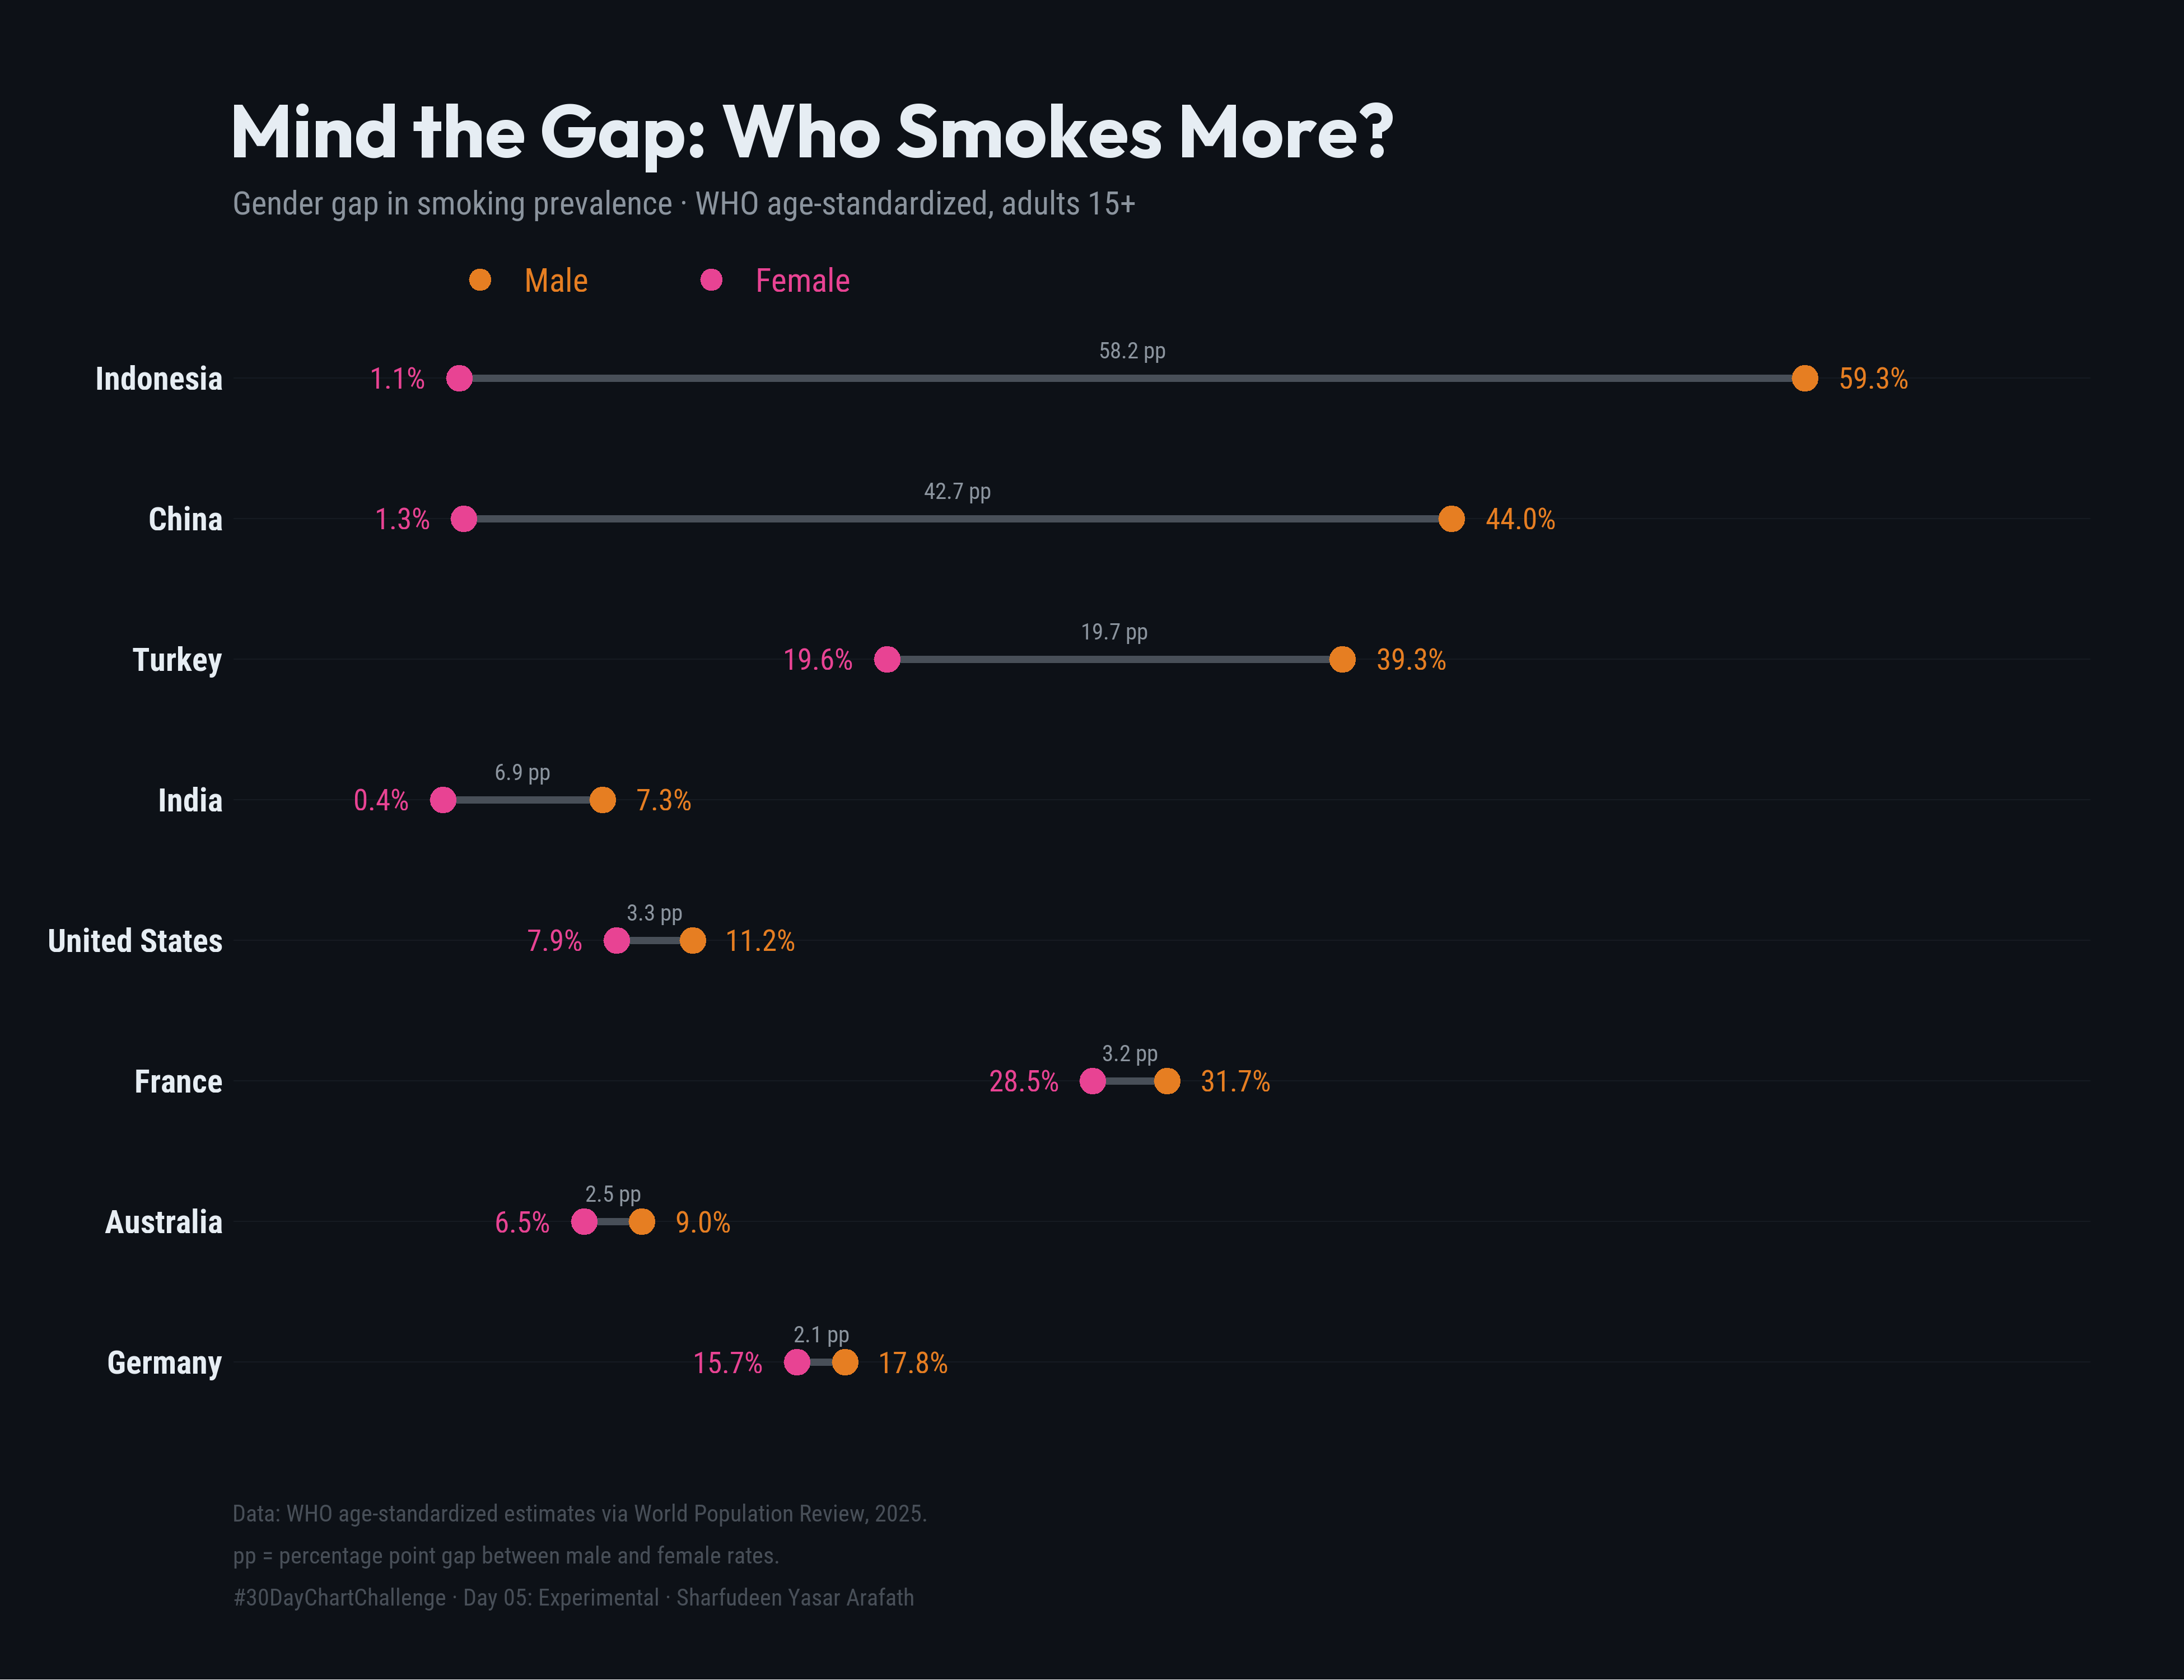

In [23]:
# — plot ----------------------------------------------------------------------

p <- ggplot(df) +

  # connecting line (the "dumbbell bar")
  geom_segment(
    aes(x = female_pct, xend = male_pct,
        y = country, yend = country),
    color = col_line, linewidth = 1.5
  ) +

  # female dot
  geom_point(
    aes(x = female_pct, y = country),
    color = col_female, size = 5
  ) +

  # male dot
  geom_point(
    aes(x = male_pct, y = country),
    color = col_male, size = 5
  ) +

  # female % label (left of dot)
  geom_text(
    aes(x = female_pct - 1.5, y = country,
        label = sprintf("%.1f%%", female_pct)),
    color = col_female, family = "roboto_condensed",
    size = 4.5, hjust = 1
  ) +

  # male % label (right of dot)
  geom_text(
    aes(x = male_pct + 1.5, y = country,
        label = sprintf("%.1f%%", male_pct)),
    color = col_male, family = "roboto_condensed",
    size = 4.5, hjust = 0
  ) +

  # gap label (center of bar)
  geom_text(
    aes(x = (male_pct + female_pct) / 2, y = country,
        label = paste0(sprintf("%.1f", gap), " pp")),
    color = txt_dim, family = "roboto_condensed",
    size = 3.5, vjust = -1.2
  ) +

  # legend dots at the top
  annotate("point", x = 2, y = 8.7, color = col_male, size = 4) +
  annotate("text", x = 4, y = 8.7, label = "Male",
           color = col_male, family = "roboto_condensed",
           size = 5, hjust = 0) +
  annotate("point", x = 12, y = 8.7, color = col_female, size = 4) +
  annotate("text", x = 14, y = 8.7, label = "Female",
           color = col_female, family = "roboto_condensed",
           size = 5, hjust = 0) +

  scale_x_continuous(limits = c(-5, 68)) +
  coord_cartesian(clip = "off") +

  labs(
    title    = "Mind the Gap: Who Smokes More?",
    subtitle = paste0(
      "Gender gap in smoking prevalence ",
      "\u00b7 WHO age-standardized, adults 15+"
    ),
    x        = "Smoking prevalence (%)",
    y        = NULL,
    caption  = paste0(
      "Data: WHO age-standardized estimates via ",
      "World Population Review, 2025.\n",
      "pp = percentage point gap between male and female rates.\n",
      "#30DayChartChallenge \u00b7 Day 05: Experimental \u00b7 ",
      "Sharfudeen Yasar Arafath"
    )
  ) +

  theme_minimal(base_family = "roboto_condensed") +
  theme(
    plot.title       = element_text(family = "outfit", face = "bold", size = 32,
                                    hjust = 0, color = txt,
                                    margin = margin(t = 20, b = 8)),
    plot.subtitle    = element_text(size = 14, hjust = 0, color = txt_dim,
                                    margin = margin(b = 25)),
    plot.caption     = element_text(size = 10, hjust = 0, color = txt_cap,
                                    margin = margin(t = 25, b = 10),
                                    lineheight = 1.5),
    axis.text.y      = element_text(size = 14, color = txt, face = "bold",
                                    margin = margin(r = 10)),
    axis.text.x      = element_blank(),
    axis.title.x     = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor   = element_blank(),
    panel.grid.major.y = element_line(color = "#161B22", linewidth = 0.3),
    plot.background  = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin      = margin(25, 40, 20, 20)
  )

p

In [24]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_05_experimental.png",
       plot = p, width = 13, height = 10, dpi = 300, bg = bg)

cat("Done — saved to chart/day_05_experimental.png\n")

Done — saved to chart/day_05_experimental.png
